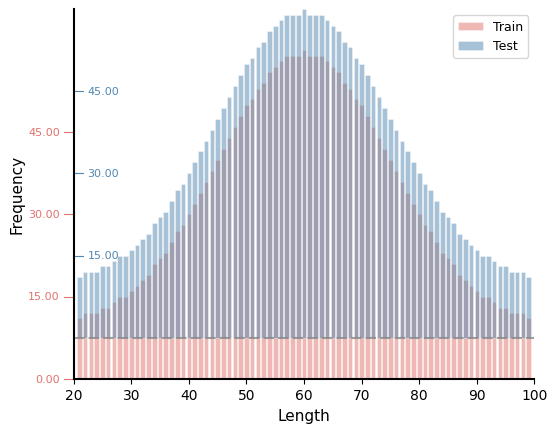

In [1]:
from plotcraft.draw import train_test_lift
import numpy as np
import matplotlib.pyplot as plt
train_data = np.arange(21, 100,dtype=int)
sigma, mu = 15, 60
y = np.exp(-(train_data - mu) ** 2 / (2 * sigma ** 2))
train_count = (y * 50 + 10).astype(int)

test_data = train_data.copy()
test_count = train_count.copy()

fig, ax = train_test_lift([train_data,train_count],[test_data,test_count],paired=False)
ax.set_xlabel('Length', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11, labelpad=35)
plt.show()

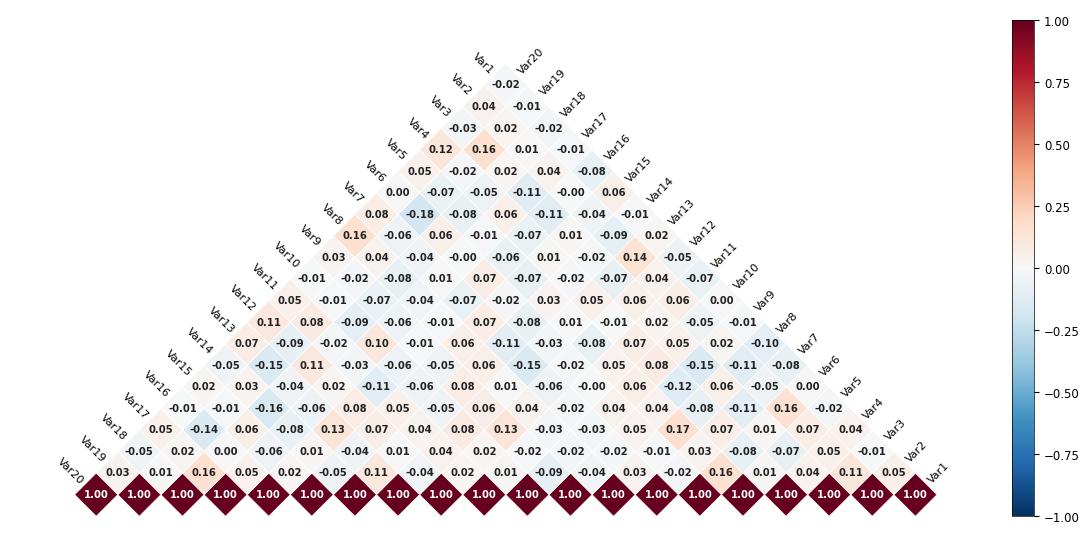

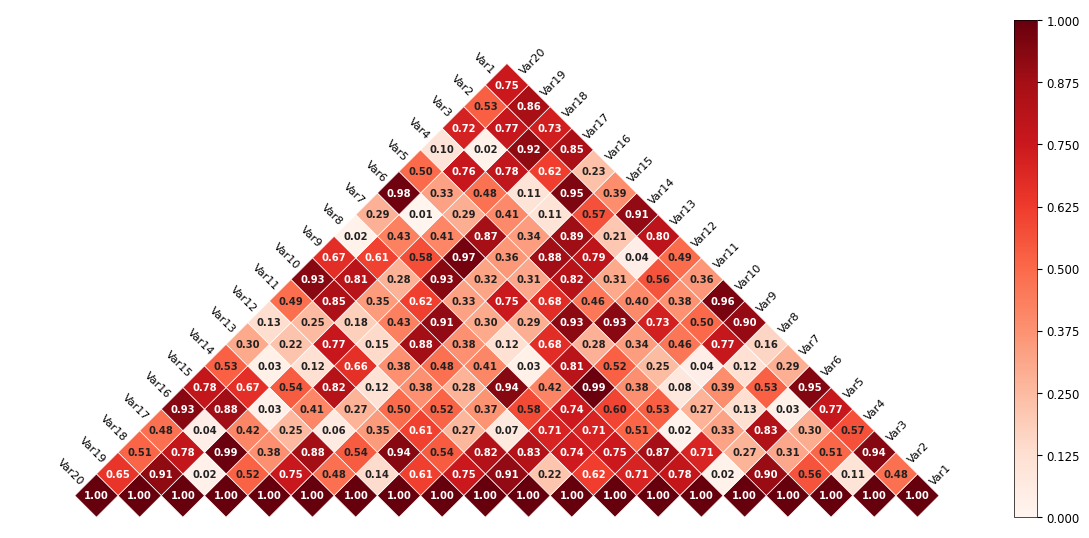

In [2]:
from plotcraft.draw import triangular_heatmap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
n_samples, n_vars = 200, 20
data = np.random.randn(n_samples, n_vars)
cols = [f"Var{i + 1}" for i in range(n_vars)]
df = pd.DataFrame(data, columns=cols)
n = n_vars
corr = np.ones((n, n))
pvalue = np.ones((n, n))
for i in range(n):
    for j in range(i + 1, n):
        r, p = stats.spearmanr(df.iloc[:, i], df.iloc[:, j])
        corr[i, j] = r
        corr[j, i] = r
        pvalue[i, j] = p
        pvalue[j, i] = p
corr_df = pd.DataFrame(corr, index=cols, columns=cols)
pvalue_df = pd.DataFrame(pvalue, index=cols, columns=cols)
fig, ax = triangular_heatmap(
    corr_df,
    annot=True,
    annot_kws={'size': 7.2},
    linewidths=0.5,
    linecolor='white',
    ticks_size=8,
    vmax=1,
    vmin=-1,
)
plt.show()
fig, ax = triangular_heatmap(
    pvalue_df,
    annot=True,
    annot_kws={'size': 7.2},
    linewidths=0.5,
    linecolor='white',
    ticks_size=8,
    vmax=1,
    vmin=0,
    cmap="Reds"
)
plt.show()

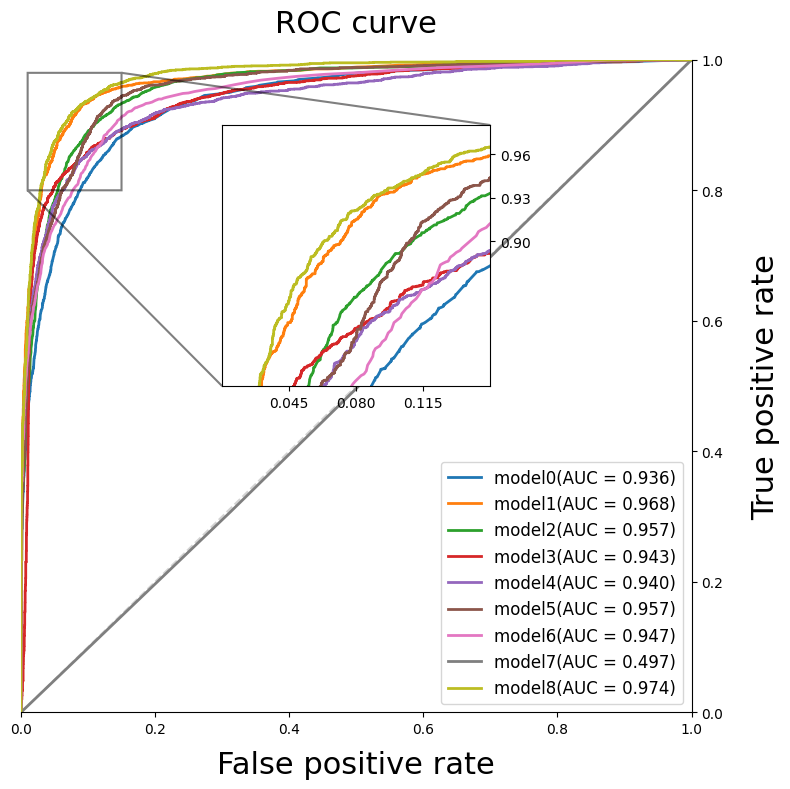

In [3]:
import numpy as np
from plotcraft.draw import enlarged_roc_curve
import matplotlib.pyplot as plt
array = np.load('./data/true_score.npy')
datas = [[array[i],array[i+1]] for i in range(0,array.shape[0],2)]
enlarged_roc_curve(*datas,labels=[f'model{i}' for i in range(len(datas))],enlarged=True,to_enlarge_frame_location=[0.01,0.80,0.15,0.98],enlarged_frame_location=[0.3, 0.5, 0.4, 0.4],enlarged_frame_xticks=[0.045, 0.08, 0.115],enlarged_frame_yticks=[0.9, 0.93, 0.96],enlarged_frame_transparent=False)
plt.show()

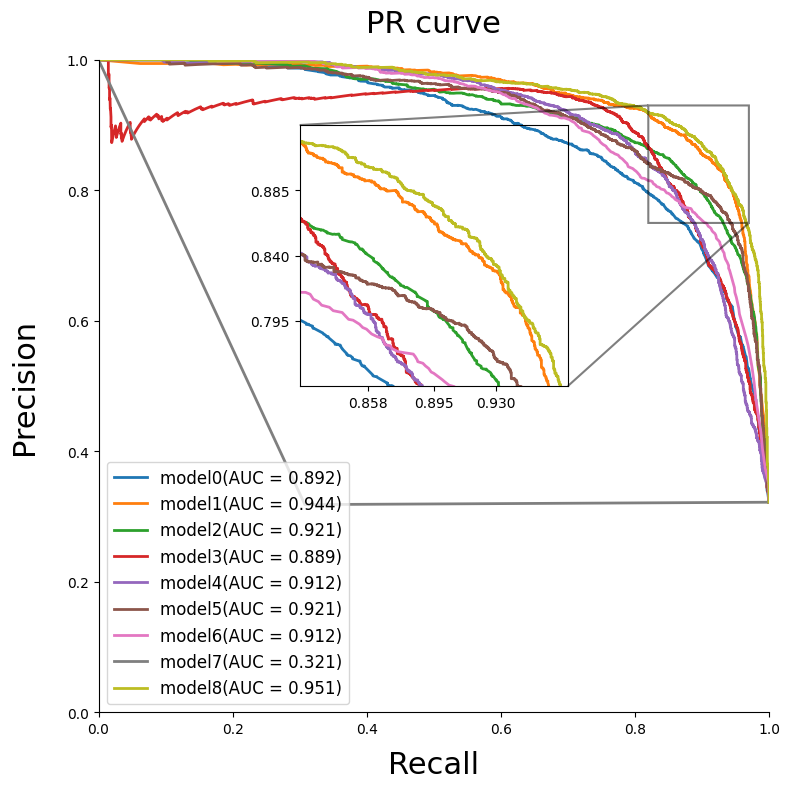

In [4]:
import numpy as np
from plotcraft.draw import enlarged_pr_curve
import matplotlib.pyplot as plt
array = np.load('./data/true_score.npy')
datas = [[array[i],array[i+1]] for i in range(0,array.shape[0],2)]
enlarged_pr_curve(*datas,labels=[f'model{i}' for i in range(len(datas))],enlarged=True,to_enlarge_frame_location=[0.82,0.75,0.97,0.93],enlarged_frame_location=[0.3, 0.5, 0.4, 0.4],enlarged_frame_xticks=[0.858,0.895,0.93],enlarged_frame_yticks=[0.795, 0.84, 0.885])
plt.show()

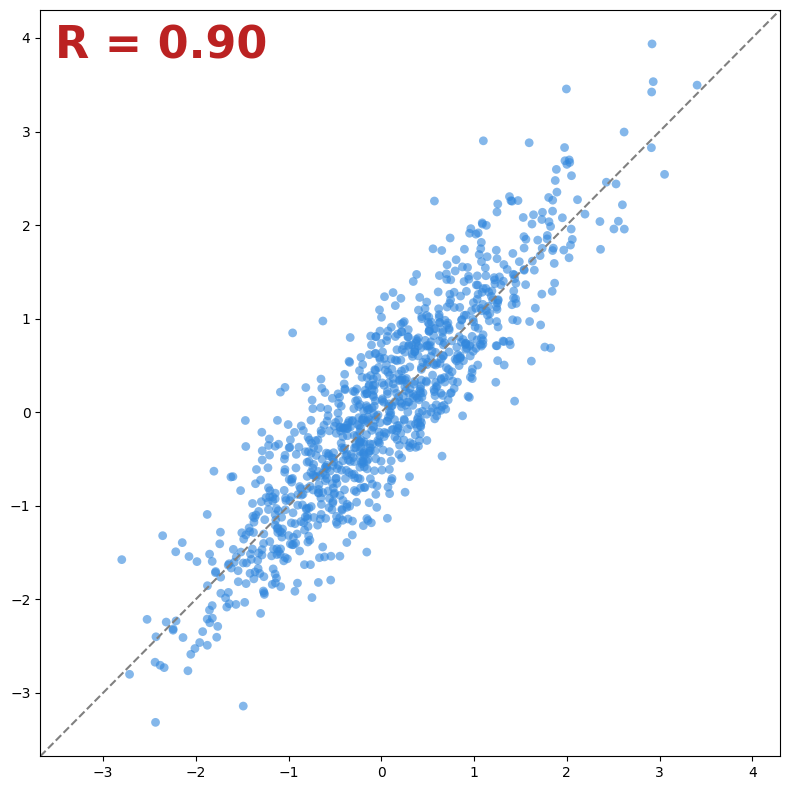

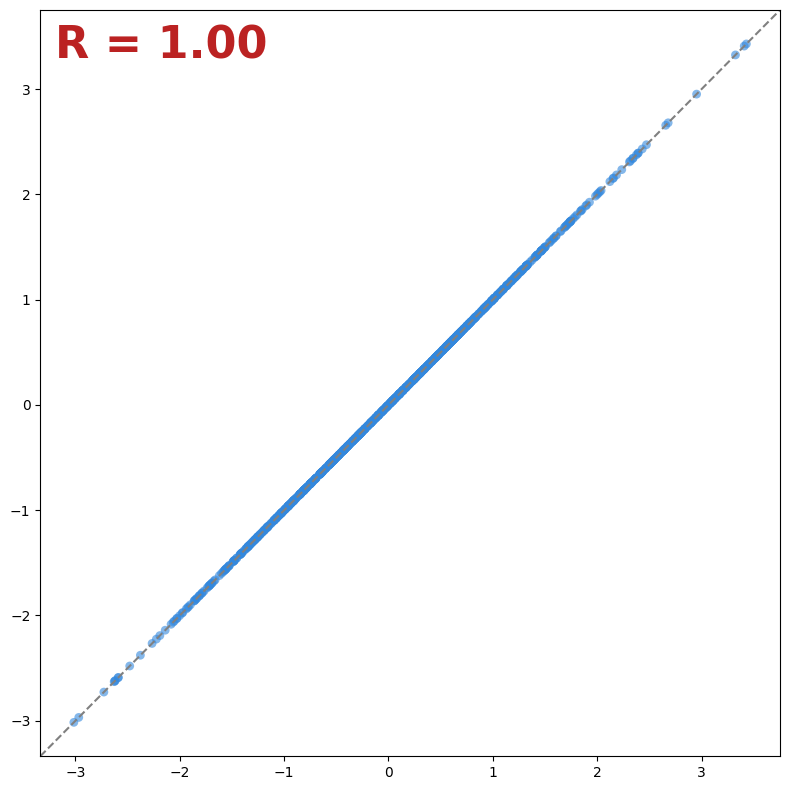

In [5]:
from plotcraft.draw import correlation_graph_between_prediction_and_reality
import numpy as np
import matplotlib.pyplot as plt
real = np.random.randn(1000)
pred = real + np.random.randn(1000) * 0.5
correlation_graph_between_prediction_and_reality(real, pred)
plt.show()

real = np.random.randn(1000)
pred = real.copy()
correlation_graph_between_prediction_and_reality(real, pred)
plt.show()

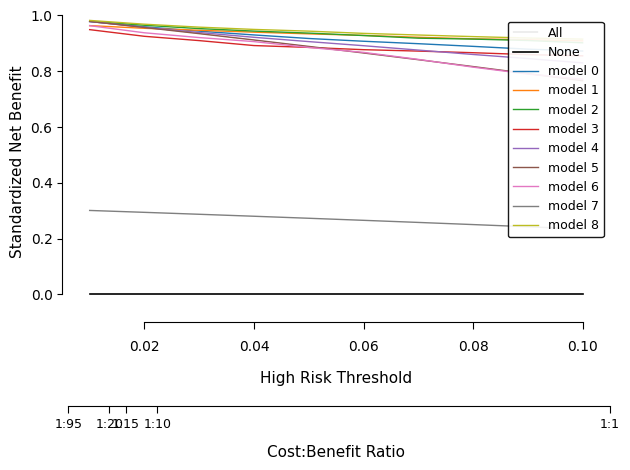

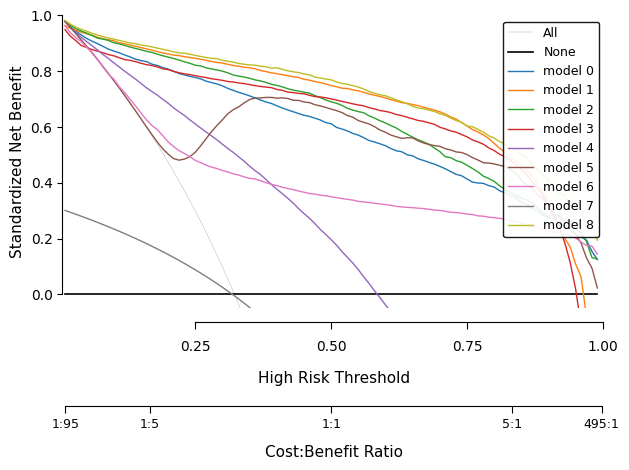

F:\AIlib\plotcraft\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


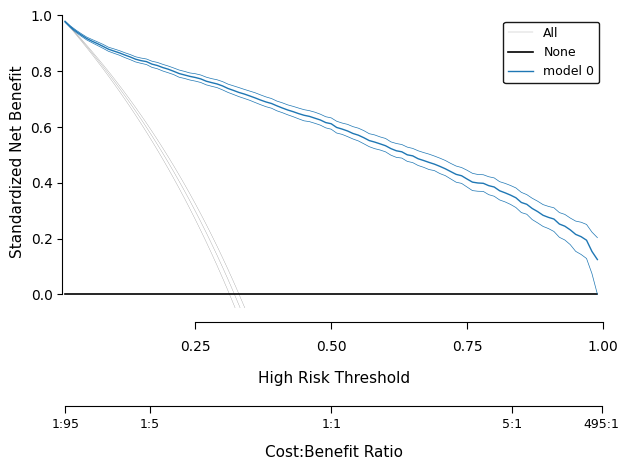

In [1]:
from plotcraft.draw import dca_curve
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
array = np.load('./data/true_score.npy')
datas = [pd.DataFrame(np.array([array[i],array[i+1]]).T,columns=['true','pred']) for i in range(0,array.shape[0],2)]
dca_curve(*datas,dataframe_cols=['true','pred'],thresholds=np.arange(0.01, 0.11, 0.01))
plt.show()

dca_curve(*datas,dataframe_cols=['true','pred'],thresholds=np.arange(0.01, 1.01, 0.01))
plt.show()

dca_curve(datas[0], dataframe_cols=['true','pred'],thresholds=np.arange(0.01, 1.01, 0.01), confidence_intervals=0.95)
plt.show()

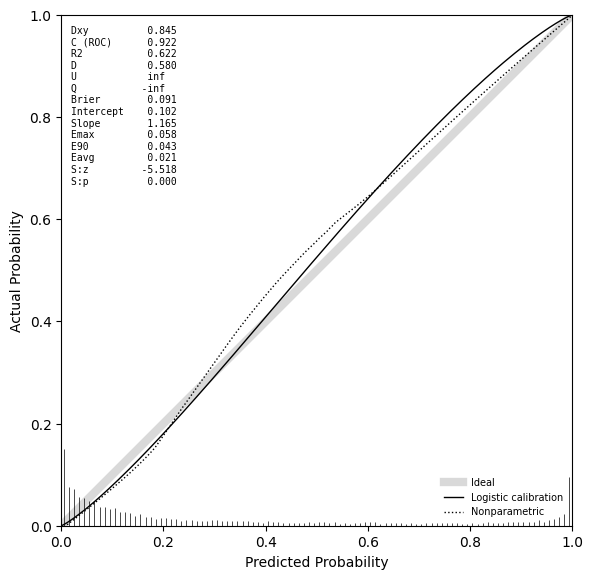

{'Dxy': np.float64(0.844659458363153), 'C (ROC)': np.float64(0.9223297291815765), 'R2': np.float64(0.621633837208709), 'D': np.float64(0.5801219042758042), 'D:Chi-sq': np.float64(4553.216582852236), 'D:p': np.float64(0.0), 'U': np.float64(inf), 'U:Chi-sq': np.float64(inf), 'U:p': np.float64(0.0), 'Q': np.float64(-inf), 'Brier': np.float64(0.09086812333667872), 'Intercept': np.float64(0.10219211288837661), 'Slope': np.float64(1.1654372330679261), 'Emax': np.float64(0.05837839669890377), 'E90': 0.04327089025931613, 'Eavg': np.float64(0.021332954687866557), 'S:z': np.float64(-5.517882581713563), 'S:p': np.float64(3.431085443228862e-08)}


In [2]:
from plotcraft.draw import calibration_curve
import matplotlib.pyplot as plt
import numpy as np
array = np.load('./data/true_score.npy')
fig, ax, result = calibration_curve(array[0],array[1])
plt.show()
print(result)

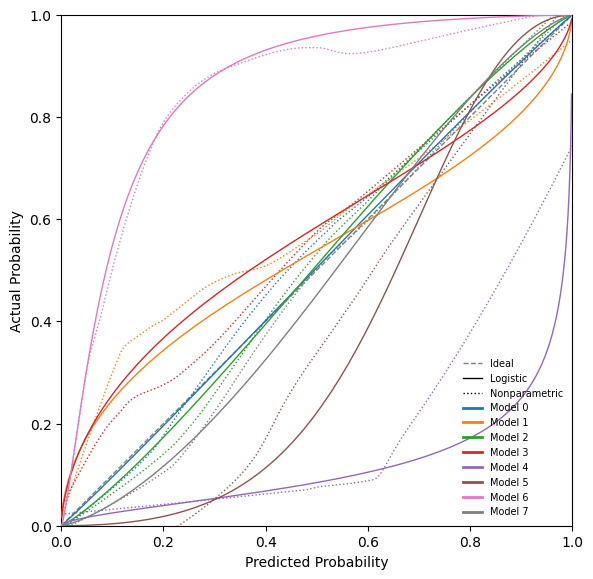

[{'Dxy': np.float64(0.872002941966288), 'C (ROC)': np.float64(0.936001470983144), 'R2': np.float64(0.6452033992804297), 'D': np.float64(0.6190336350339604), 'D:Chi-sq': np.float64(5366.1645148393345), 'D:p': np.float64(0.0), 'U': np.float64(-1.7347180374161377e-06), 'U:Chi-sq': np.float64(1.9849651987697143), 'U:p': np.float64(0.37065535907974756), 'Q': np.float64(0.6190353697519978), 'Brier': np.float64(0.09086812333667872), 'Intercept': np.float64(0.02058362255076217), 'Slope': np.float64(1.0333479048681826), 'Emax': np.float64(0.05837839669890377), 'E90': 0.04327089025931613, 'Eavg': np.float64(0.021332954687866633), 'S:z': np.float64(-5.517882581713604), 'S:p': np.float64(3.431085443228063e-08)}, {'Dxy': np.float64(0.9367248588346428), 'C (ROC)': np.float64(0.9683624294173214), 'R2': np.float64(0.7413454055464552), 'D': np.float64(0.7557169327347845), 'D:Chi-sq': np.float64(6550.798656012377), 'D:p': np.float64(0.0), 'U': np.float64(0.08669965164489879), 'U:Chi-sq': np.float64(753.

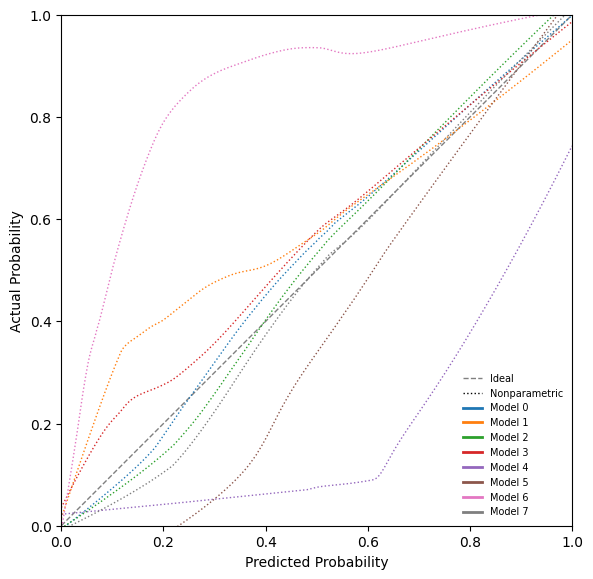

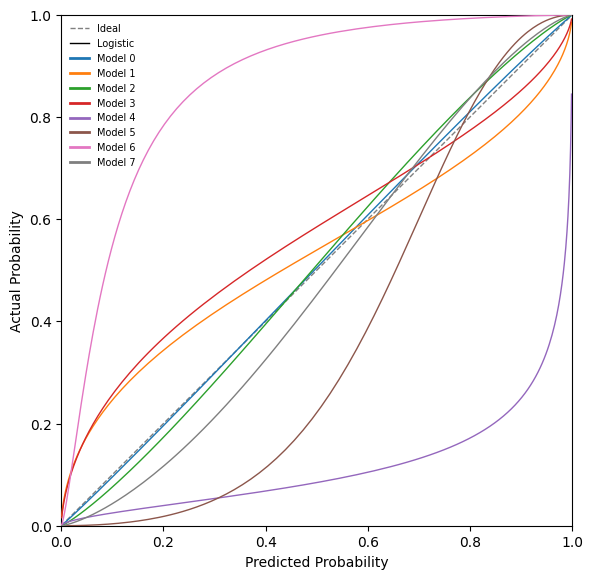

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plotcraft.draw import calibration_curves
array = np.load('./data/true_score.npy')
datas = [pd.DataFrame(np.array([array[i],array[i+1]]).T,columns=['true','pred']) for i in range(0,array.shape[0],2) if i != 14]
fig, ax, all_stats = calibration_curves(*datas,dataframe_cols=['true','pred'])
plt.show()
print(all_stats)
fig, ax, all_stats = calibration_curves(*datas, dataframe_cols=['true', 'pred'], logistic_cal=False)
plt.show()
fig, ax, all_stats = calibration_curves(*datas, dataframe_cols=['true', 'pred'], nonparametric_cal=False)
plt.show()

function: f(x) = tan(x)
domain of definition: Complement(Reals, Union(ImageSet(Lambda(_n, 2*_n*pi + pi/2), Integers), ImageSet(Lambda(_n, 2*_n*pi + 3*pi/2), Integers)))
Drawing interval(7 segment): [(-10.0, -7.853981633974), (-7.853981633974, -4.712388980385), (-4.712388980385, -1.570796326795), (-1.570796326795, 1.570796326795), (1.570796326795, 4.712388980385), (4.712388980385, 7.853981633974), (7.853981633974, 10.0)]
vertical asymptotes (with a total of 6 lines): ['x=-7.854', 'x=-4.7124', 'x=-1.5708', 'x=1.5708', 'x=4.7124', 'x=7.854']


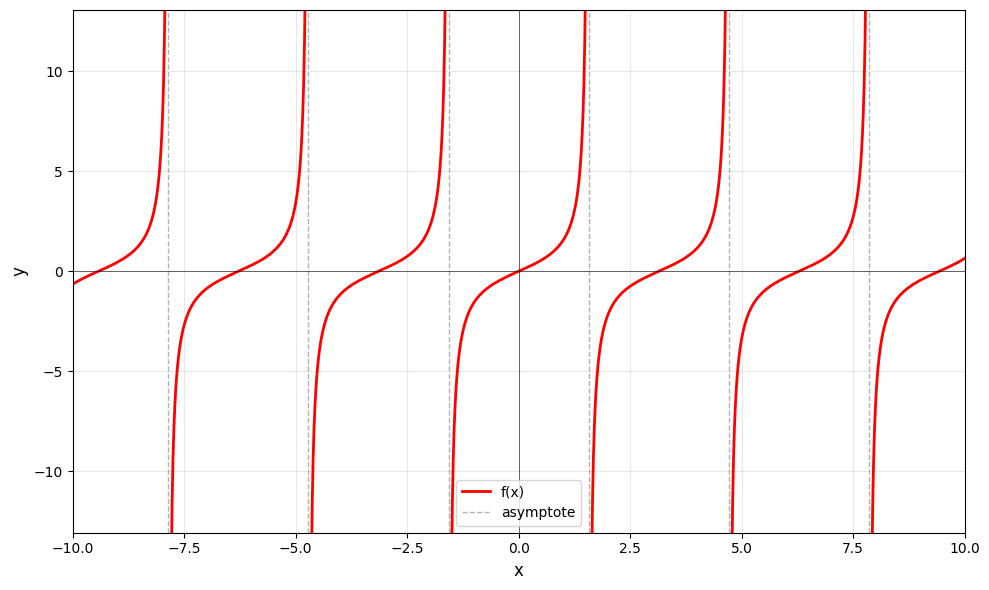

function: f(x) = sqrt(x**2 - 1)
domain of definition: Union(Interval(-oo, -1), Interval(1, oo))
Drawing interval(2 segment): [(-10.0, -1.0), (1.0, 10.0)]
vertical asymptotes: None
obliqueasymptotes: y = 1.0x + 0.0  (direction: +inf)
obliqueasymptotes: y = -1.0x + 0.0  (direction: -inf)


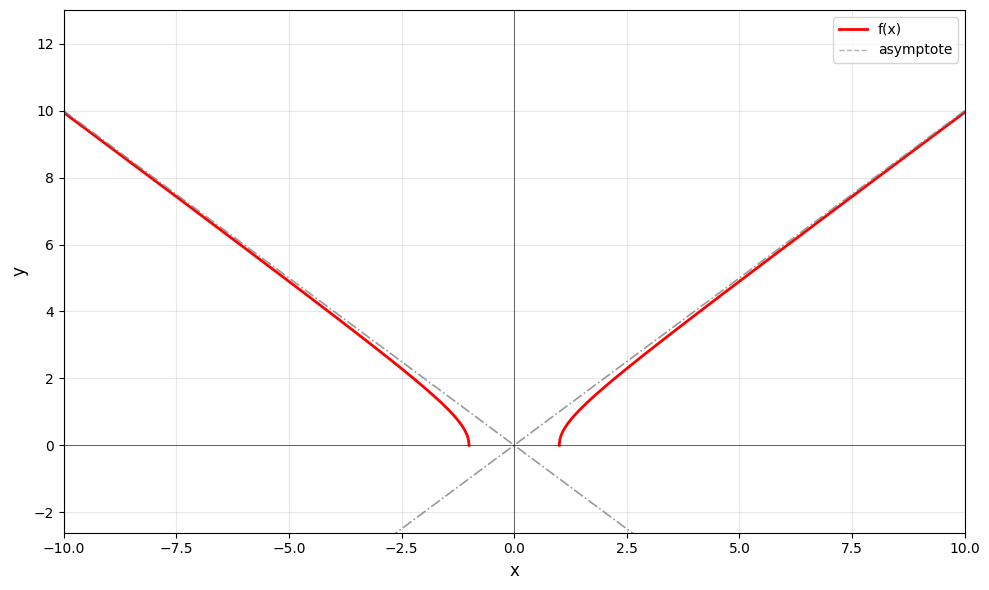

function: f(x) = atan(x)
domain of definition: Reals
Drawing interval(1 segment): [(-10.0, 10.0)]
vertical asymptotes: None
horizontalasymptotes: y = 1.5707963267948966  (direction: +inf)
horizontalasymptotes: y = -1.5707963267948966  (direction: -inf)


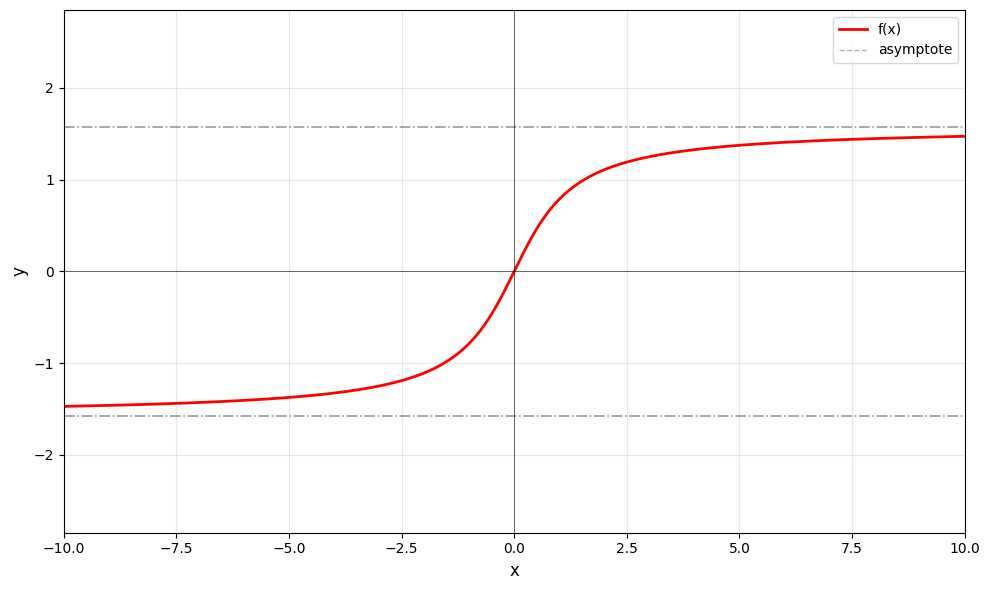

function: f(x) = sin(x)/x
domain of definition: Union(Interval.open(-oo, 0), Interval.open(0, oo))
Drawing interval(2 segment): [(-10.0, 0.0), (0.0, 10.0)]
vertical asymptotes: None
horizontalasymptotes: y = 0.0  (direction: both)


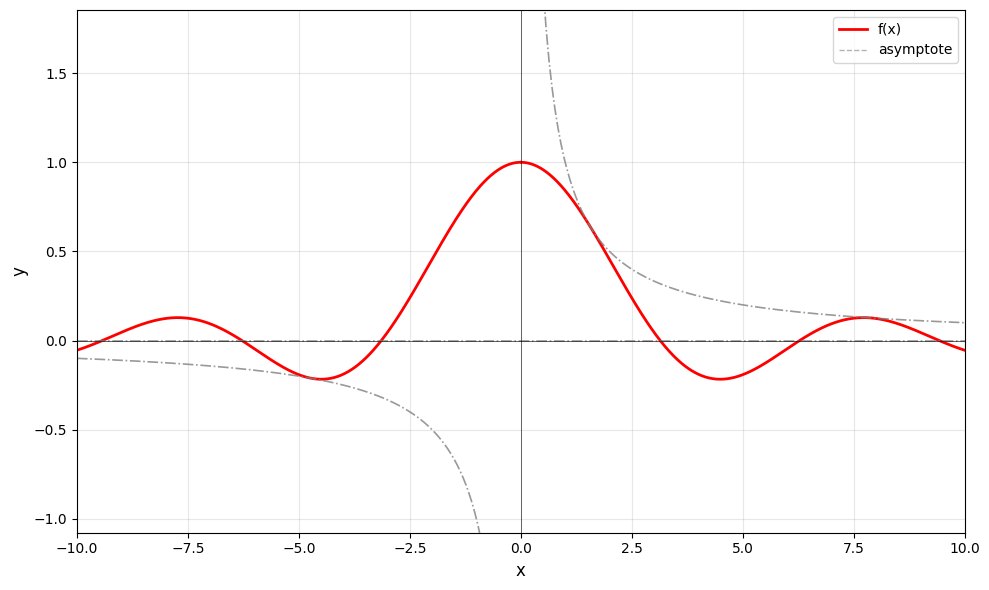

In [1]:
from plotcraft.draw import plot_function_with_asymptote
from sympy import symbols, atan, tan, sqrt, sin
import matplotlib.pyplot as plt
x = symbols('x')
f = tan(x)
plot_function_with_asymptote(f, x, x_range=(-10, 10), n_points=1000)
plt.show()
f = sqrt(x**2 - 1)
plot_function_with_asymptote(f, x, x_range=(-10, 10), n_points=1000)
plt.show()
f = atan(x)
plot_function_with_asymptote(f, x, x_range=(-10, 10), n_points=1000)
plt.show()
f = sin(x) / x
plot_function_with_asymptote(
    f, x,
    x_range=(-10, 10),
    n_points=1000,
    add_asymptote=[lambda t: 1 / t],
)
plt.show()